# L5.5 — Sampling Strategies

Hands-on notebook for the lesson [`5-5-sampling.mdx`](../../llm-quest-theory/level-5/5-5-sampling.mdx).

> **Learning objectives**
> - Implement greedy, random, temperature, top-k, top-p and repetition-penalty samplers from scratch.
> - Run the same prompt through each on a real pretrained LM (`distilgpt2`) and compare diversity.
> - Measure the distribution's entropy as `temperature` changes — empirically confirm the theory.
> - Observe how top-p adapts the candidate pool to the context, while top-k does not.

## Connection to the theory
Covers **§1–§11** of the source `.mdx`. This is the knob you will keep reaching for every time you deploy an LLM.

In [1]:
# ---- Setup ----
import os, math, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import matplotlib.pyplot as plt
import torch

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Load a real pretrained LM
`distilgpt2` is ~330 MB — small enough to run on CPU at a few tokens per second. First run will download weights.

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
MODEL_NAME = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print("model:", MODEL_NAME, "   params:", sum(p.numel() for p in model.parameters()))

model: distilgpt2    params: 81912576


## 2. One forward pass — what do raw logits look like?
We feed the prompt, grab the last-token logits, and inspect their top 10 candidates.

In [3]:
PROMPT = "The best way to learn programming is"
input_ids = tokenizer.encode(PROMPT, return_tensors="pt")
with torch.no_grad():
    logits = model(input_ids).logits[0, -1]    # last position logits

# Top 10 next-token candidates
topk = logits.topk(10)
for score, idx in zip(topk.values.tolist(), topk.indices.tolist()):
    print(f"  logit {score:+.2f}   token = {tokenizer.decode([idx])!r}")

  logit -26.66   token = ' to'
  logit -28.06   token = ' by'
  logit -29.03   token = ' through'
  logit -29.29   token = ' with'
  logit -30.52   token = ' in'
  logit -30.56   token = ' not'
  logit -30.74   token = ' for'
  logit -31.06   token = ' using'
  logit -31.33   token = ' from'
  logit -31.49   token = ' via'


## 3. Samplers from scratch
Given a logits vector, each sampler returns one chosen token ID.

In [4]:
def greedy_sample(logits):
    return int(logits.argmax())

def temperature_sample(logits, T, rng=None):
    if T <= 1e-6:
        return greedy_sample(logits)
    probs = (logits / T).softmax(dim=-1)
    return int(torch.multinomial(probs, 1, generator=rng).item())

def top_k_sample(logits, k, T=1.0, rng=None):
    values, indices = torch.topk(logits, k)
    new_logits = torch.full_like(logits, float("-inf"))
    new_logits[indices] = values
    return temperature_sample(new_logits, T, rng=rng)

def top_p_sample(logits, p, T=1.0, rng=None):
    # Sort in descending order, keep the smallest prefix whose cumulative prob >= p.
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    probs = (sorted_logits / T).softmax(dim=-1)
    cum   = probs.cumsum(dim=-1)
    keep  = cum < p
    # Always keep the very top token
    keep[0] = True
    # Shift so we include the first token whose cumsum crosses p
    cutoff = int(keep.sum().item())
    cutoff = max(cutoff, 1)
    kept_probs = probs[:cutoff] / probs[:cutoff].sum()
    pick = int(torch.multinomial(kept_probs, 1, generator=rng).item())
    return int(sorted_idx[pick].item())

def apply_repetition_penalty(logits, generated, alpha=1.2):
    for token_id in set(generated):
        logits[token_id] = logits[token_id] / alpha if logits[token_id] > 0 else logits[token_id] * alpha
    return logits

# Smoke test
rng = torch.Generator().manual_seed(SEED)
print("greedy :", tokenizer.decode([greedy_sample(logits)]))
print("T=1.0 :", tokenizer.decode([temperature_sample(logits, T=1.0, rng=rng)]))
print("top-k :", tokenizer.decode([top_k_sample(logits, k=5, T=1.0, rng=rng)]))
print("top-p :", tokenizer.decode([top_p_sample(logits, p=0.9, T=1.0, rng=rng)]))

greedy :  to
T=1.0 :  to
top-k :  to
top-p :  to


## 4. Generation loop
A generic generator that takes any sampler and produces `max_new_tokens`.

In [5]:
def generate(prompt, sampler_fn, max_new_tokens=30, repetition_alpha=None, rng=None):
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    generated = input_ids[0].tolist()
    for _ in range(max_new_tokens):
        with torch.no_grad():
            step_logits = model(torch.tensor([generated])).logits[0, -1].clone()
        if repetition_alpha:
            step_logits = apply_repetition_penalty(step_logits, generated, repetition_alpha)
        next_id = sampler_fn(step_logits, rng=rng) if rng is not None else sampler_fn(step_logits)
        generated.append(next_id)
        if next_id == tokenizer.eos_token_id: break
    return tokenizer.decode(generated, skip_special_tokens=True)

# Run each strategy on the same prompt
print("=== greedy (T=0) ===")
print(generate(PROMPT, greedy_sample, max_new_tokens=30))

rng = torch.Generator().manual_seed(SEED)
print("\n=== temperature 0.7 ===")
print(generate(PROMPT, lambda l, rng=rng: temperature_sample(l, T=0.7, rng=rng),
               max_new_tokens=30, rng=rng))

rng = torch.Generator().manual_seed(SEED)
print("\n=== top-k = 40, T = 1.0 ===")
print(generate(PROMPT, lambda l, rng=rng: top_k_sample(l, k=40, T=1.0, rng=rng),
               max_new_tokens=30, rng=rng))

rng = torch.Generator().manual_seed(SEED)
print("\n=== top-p = 0.9, T = 1.0 ===")
print(generate(PROMPT, lambda l, rng=rng: top_p_sample(l, p=0.9, T=1.0, rng=rng),
               max_new_tokens=30, rng=rng))

=== greedy (T=0) ===
The best way to learn programming is to learn from the experience of the programmer.






















=== temperature 0.7 ===
The best way to learn programming is to sit down and learn something new. You can learn a lot about programming with a good computer, and you can learn some new programming without getting discouraged

=== top-k = 40, T = 1.0 ===
The best way to learn programming is to sit down and learn something different. You can learn a lot about programming with any of the tools here. I’m sure you can try

=== top-p = 0.9, T = 1.0 ===
The best way to learn programming is to take a short lesson from various C++ programming languages and see how they affect programming performance. Read my articles on those, and follow along to learn


## 5. Temperature sweep — entropy of the distribution
At each temperature we look at the distribution over the next token after the same prompt. Low `T` concentrates mass on a few tokens (low entropy); high `T` spreads it out (higher entropy).

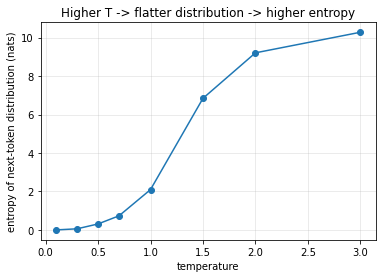

In [6]:
def distribution_entropy(logits, T):
    p = (logits / max(T, 1e-6)).softmax(dim=-1)
    return float(-(p * (p + 1e-12).log()).sum())

Ts = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
ent = [distribution_entropy(logits, T) for T in Ts]

fig, ax = plt.subplots()
ax.plot(Ts, ent, "o-")
ax.set_xlabel("temperature"); ax.set_ylabel("entropy of next-token distribution (nats)")
ax.grid(alpha=0.3)
ax.set_title("Higher T -> flatter distribution -> higher entropy")
plt.show()

## 6. Top-p adapts to context; top-k does not
For a **sure** context (e.g. right after a period) only 3–5 tokens are plausible. For an **ambiguous** context, dozens are. We measure how many tokens top-p keeps in each case.

In [7]:
def top_p_size(logits, p, T=1.0):
    probs = (logits / T).softmax(dim=-1).sort(descending=True).values
    cum = probs.cumsum(dim=-1)
    # smallest prefix whose cumsum >= p
    return int((cum < p).sum().item()) + 1

contexts = {
    "confident  (after period)": "The experiment was a success. Next, ",
    "open-ended (starting novel)": "Once upon a time, in a distant galaxy, ",
    "structured (code-like)"    : "def factorial(n):\n    if n == 0:\n        return",
}
for label, ctx in contexts.items():
    ids = tokenizer.encode(ctx, return_tensors="pt")
    with torch.no_grad():
        ctx_logits = model(ids).logits[0, -1]
    s = top_p_size(ctx_logits, p=0.9)
    print(f"  {label:<30} top-p=0.9 keeps {s:>3} tokens")

  confident  (after period)      top-p=0.9 keeps  88 tokens
  open-ended (starting novel)    top-p=0.9 keeps 121 tokens
  structured (code-like)         top-p=0.9 keeps 151 tokens


Notice the pool size changes dramatically with context — top-k with a fixed number would either be wastefully large (confident contexts) or dangerously small (open-ended contexts).

## 7. Repetition penalty — fixing the broken record
Small LMs often loop. Compare greedy with and without a repetition penalty.

In [8]:
LOOPY = "She said: I love cats. I love cats. I love cats."
print("=== greedy, no penalty ===")
print(generate(LOOPY, greedy_sample, max_new_tokens=25))
print("\n=== greedy, repetition penalty 1.3 ===")
print(generate(LOOPY, greedy_sample, max_new_tokens=25, repetition_alpha=1.3))

=== greedy, no penalty ===
She said: I love cats. I love cats. I love cats. I love cats. I love cats. I love cats. I love cats. I love cats. I love cats. I

=== greedy, repetition penalty 1.3 ===
She said: I love cats. I love cats. I love cats.
"I'm a cat lover, and it's not just me," she told the BBC in an interview with The Sun


## 8. Quick checks

In [9]:
# Entropy must be monotonically non-decreasing in T
assert all(ent[i] <= ent[i + 1] + 1e-6 for i in range(len(ent) - 1)), "entropy must grow with T"
# Greedy gives the same output twice in a row
g1 = generate(PROMPT, greedy_sample, max_new_tokens=20)
g2 = generate(PROMPT, greedy_sample, max_new_tokens=20)
assert g1 == g2, "greedy must be deterministic"
# Random sampling with different seeds gives different outputs
rng_a = torch.Generator().manual_seed(0)
rng_b = torch.Generator().manual_seed(1)
out_a = generate(PROMPT, lambda l, rng=rng_a: temperature_sample(l, T=1.0, rng=rng_a), max_new_tokens=10, rng=rng_a)
out_b = generate(PROMPT, lambda l, rng=rng_b: temperature_sample(l, T=1.0, rng=rng_b), max_new_tokens=10, rng=rng_b)
assert out_a != out_b, "random sampling should diverge across seeds"
# Top-p should keep more tokens when the next token is genuinely uncertain.
# Right-after-a-period prompts are the most confident for distilgpt2; open-ended novels are not.
ids_confident = tokenizer.encode(contexts["confident  (after period)"], return_tensors="pt")
ids_open      = tokenizer.encode(contexts["open-ended (starting novel)"], return_tensors="pt")
with torch.no_grad():
    size_confident = top_p_size(model(ids_confident).logits[0, -1], p=0.9)
    size_open      = top_p_size(model(ids_open).logits[0, -1], p=0.9)
print(f"confident context keeps {size_confident}  open-ended keeps {size_open}")
assert size_open > size_confident, "top-p should keep more candidates in open-ended contexts"
print("OK — samplers behave, entropy tracks T, top-p adapts to context.")


confident context keeps 88  open-ended keeps 121
OK — samplers behave, entropy tracks T, top-p adapts to context.


## Reflection questions

1. Why should you never combine `T = 0` with `top_p < 1`? What does `T = 0` already guarantee?
2. For JSON extraction, which setting would you recommend — `T = 0`, `T = 0.3 + top_p = 0.95`, or `T = 1.0 + top_p = 0.9`? Why?
3. In a RAG system where the LLM should stick to the retrieved passages, would you pick a low or high temperature, and why?
4. Beam search (in the theory) aims for "globally best" sequences. Why do LLM chat APIs use top-p instead of beam search by default?

## References
- Source theory: [`5-5-sampling.mdx`](../../llm-quest-theory/level-5/5-5-sampling.mdx)
- Next: [`5-6-chatbot-boss`](5-6-chatbot-boss.ipynb) — the Level 5 boss, a local chat loop.